---

## Ejercicio 19 — Modelado de la ley de enfriamiento mediante una red neuronal

En este ejercicio aproximaremos la ley de enfriamiento de Netwon con una red neuronal. Ésta describe cómo varía la temperatura de un objeto en función del tiempo cuando se encuentra en un ambiente con temperatura constante. La ecuación del proceso es 

$$
T(t) = T_{amb} + (T_0 - T_{amb}) \exp(-kt),
$$

en donde $T(t)$ es la temperatura al tiempo $t$, $T_0$ la temperatura inicial, $T_{amb}$ la ambiente y $k$ la constante de enfriamiento.

Se busca entrenar un modelo de red neuronal (tipo MLP) que aprenda a aproximar esta función a partir de datos simulados con ruido. 

1. Implementar una función que genere datos sintéticos a partir de la ley de enfriamiento de Newton. Agregar ruido gaussiano a las observaciones para simular mediciones reales y generar una base de datos de 1000 puntos. Visualizar los datos en un gráfico de dispersión.

2. Dividir los datos en entrenamiento y prueba y generar un dataloader con tamaño de batch de 32.

3. Implementar el modelo MLP en pytorch utilizando `torch.nn.Module`. El modelo debe recibir como entrada el tiempo $t$ y devolver la temperatura estimada. Utilizar al menos una capa oculta y una función de activación no lineal. 

5. Definir una función de pérdida adecuada para regresión y un optimizador utilizar una tasa de aprendizaje de $0.002$. Implementar un loop de entrenamiento que haga un forward pass, calcule la pérdida, haga un backward pass, y actualice los parámetros. Entrenar el modelo con los datos de entrenamiento durante 4000 épocas

4. Mostrar el valor de la pérdida cada cierta cantidad de épocas y analizar si el modelo está aprendiendo correctamente. 

5. Comparar visualmente las predicciones del modelo con los datos de prueba. Graficar la curva de pérdida.

In [ ]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Reproducibilidad
torch.manual_seed(42)

# 1) Generación de datos sintéticos (Ley de enfriamiento de Newton + ruido)
T0 = 100.0
Tamb = 25.0
k = 0.05
t_max = 100.0
n_puntos = 1000

t = torch.linspace(0, t_max, n_puntos, dtype=torch.float32)
temperatura = Tamb + (T0 - Tamb) * torch.exp(-k * t)
ruido = torch.randn_like(temperatura) * 2.0

y_obs = (temperatura + ruido).unsqueeze(1)
X_obs = t.unsqueeze(1)

# 2) Split train/val/test y dataloaders
dataset = TensorDataset(X_obs, y_obs)
n_total = len(dataset)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# 3) Modelo con configuración fija
class MLPEnfriamiento(nn.Module):
    def __init__(self, hidden_dim: int = 128, activation: str = "relu"):
        super().__init__()
        act = nn.ReLU() if activation == "relu" else nn.Tanh()
        self.layers = nn.Sequential(
            nn.Linear(1, hidden_dim),
            act,
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.layers(x)


def build_loss(loss_name: str):
    if loss_name == "mse":
        return nn.MSELoss()
    if loss_name == "huber":
        return nn.HuberLoss()
    if loss_name == "mae":
        return nn.L1Loss()
    raise ValueError(f"Loss desconocida: {loss_name}")


def build_optimizer(opt_name: str, params, lr: float):
    if opt_name == "adam":
        return torch.optim.Adam(params, lr=lr)
    if opt_name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr)
    if opt_name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    raise ValueError(f"Optimizador desconocido: {opt_name}")


def run_epoch(model, loader, loss_fn, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_n = 0
    for batch_x, batch_y in loader:
        if training:
            optimizer.zero_grad()

        pred = model(batch_x)
        loss = loss_fn(pred, batch_y)

        if training:
            loss.backward()
            optimizer.step()

        bs = batch_x.size(0)
        total_loss += loss.item() * bs
        total_n += bs

    return total_loss / total_n


def train_model(config, max_epochs=4000):
    model = MLPEnfriamiento(hidden_dim=config["hidden_dim"], activation=config["activation"])
    loss_fn = build_loss(config["loss"])
    optimizer = build_optimizer(config["optimizer"], model.parameters(), config["lr"])

    history_train = []
    history_val = []

    best_val = float("inf")
    best_epoch = -1

    for epoch in range(max_epochs):
        train_loss = run_epoch(model, train_loader, loss_fn, optimizer)
        val_loss = run_epoch(model, val_loader, loss_fn, optimizer=None)

        history_train.append(train_loss)
        history_val.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1:4d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

    # Métricas en test
    test_mse = run_epoch(model, test_loader, nn.MSELoss(), optimizer=None)
    test_mae = run_epoch(model, test_loader, nn.L1Loss(), optimizer=None)

    return {
        "config": config,
        "model": model,
        "best_val_loss": best_val,
        "best_epoch": best_epoch,
        "test_mse": test_mse,
        "test_mae": test_mae,
        "history": {
            "train": history_train,
            "val": history_val,
        },
    }


# 4) Entrenamiento
config = {
    "hidden_dim": 128,
    "activation": "relu",
    "loss": "huber",
    "optimizer": "rmsprop",
    "lr": 0.002,
}

result = train_model(config, max_epochs=4000)
model = result["model"]

print("\nConfiguración usada:")
print(result["config"])
print(f"Best val loss: {result['best_val_loss']:.6f} (epoch {result['best_epoch']})")
print(f"Test MSE: {result['test_mse']:.6f}")
print(f"Test MAE: {result['test_mae']:.6f}")

# 5) Predicción con el modelo entrenado
model.eval()
with torch.no_grad():
    t_test = torch.linspace(0, t_max, n_puntos).unsqueeze(1)
    pred_model = model(t_test)

Epoch  100 | train loss: 2.562689 | val loss: 2.162490
Epoch  200 | train loss: 1.514275 | val loss: 1.496488
Epoch  300 | train loss: 2.138442 | val loss: 1.210801
Epoch  400 | train loss: 1.887690 | val loss: 1.331861
Epoch  500 | train loss: 1.503180 | val loss: 1.773569
Epoch  600 | train loss: 1.334110 | val loss: 1.164834
Epoch  700 | train loss: 1.332832 | val loss: 1.226447
Epoch  800 | train loss: 1.457614 | val loss: 1.425592
Epoch  900 | train loss: 1.347167 | val loss: 1.084550
Epoch 1000 | train loss: 1.332603 | val loss: 1.184119
Epoch 1100 | train loss: 1.228363 | val loss: 1.339215
Epoch 1200 | train loss: 1.335117 | val loss: 1.106008
Epoch 1300 | train loss: 1.312142 | val loss: 1.076514
Epoch 1400 | train loss: 1.430875 | val loss: 1.607627
Epoch 1500 | train loss: 1.259062 | val loss: 1.218295
Epoch 1600 | train loss: 1.249927 | val loss: 1.331994
Epoch 1700 | train loss: 1.247712 | val loss: 1.332114
Epoch 1800 | train loss: 1.266314 | val loss: 1.135766
Epoch 1900

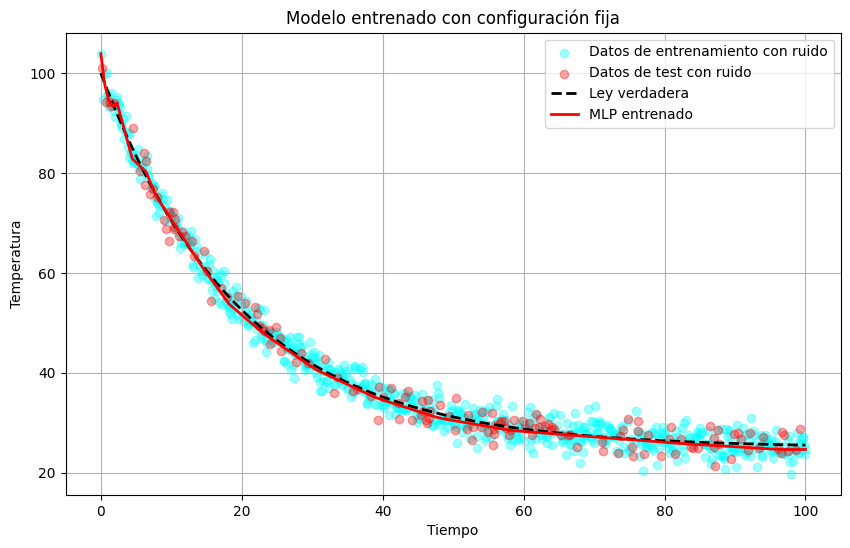

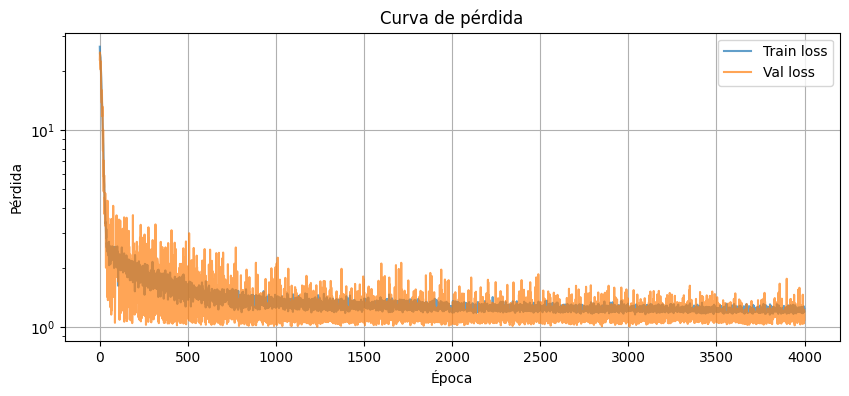

In [14]:
plt.figure(figsize=(10, 6))
train_x_plot = X_obs[train_dataset.indices]
train_y_plot = y_obs[train_dataset.indices]
test_x_plot = X_obs[test_dataset.indices]
test_y_plot = y_obs[test_dataset.indices]
plt.scatter(train_x_plot.numpy(), train_y_plot.numpy(), alpha=0.35, color="cyan", label="Datos de entrenamiento con ruido")
plt.scatter(test_x_plot.numpy(), test_y_plot.numpy(), alpha=0.35, color="red", label="Datos de test con ruido")
plt.plot(t_test.numpy(), temperatura.numpy(), color="black", linewidth=2, linestyle="--", label="Ley verdadera")
plt.plot(t_test.numpy(), pred_model.numpy(), color="red", linewidth=2, label="MLP entrenado")
plt.xlabel("Tiempo")
plt.ylabel("Temperatura")
plt.title("Modelo entrenado con configuración fija")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.semilogy(result["history"]["train"], label="Train loss", alpha = 0.7)
plt.semilogy(result["history"]["val"], label="Val loss", alpha = 0.7)
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curva de pérdida")
plt.legend()
plt.grid(True)
plt.show()